# First-Order vs Second-Order Optimization

the Project is about comparing first order methods VS second order methods.

the problem we have chosen is logistic regression, a convex machine learning algorithm

we have used gradient descent as a first order method and newton's method as second order one

## import some useful libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer, load_wine, load_digits, fetch_olivetti_faces, load_svmlight_files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import time
import warnings
warnings.filterwarnings("ignore")
import os
import urllib.request
from scipy.optimize import minimize

## logistic regression useful methods


In [6]:
def sigmoid(z):
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

# Binary logistic loss for y in {0, 1}, with L2 regularization.
# Important: the last column is the bias/intercept, so we do NOT regularize w[-1].
def cross_entropy_loss(X, w, y, lam=1e-3):
    z = X @ w
    data_loss = np.mean(np.logaddexp(0, z) - y * z)
    reg_loss = 0.5 * lam * np.sum(w[:-1] ** 2)
    return data_loss + reg_loss

# Gradient  ∇L = (1/n) Xᵀ(p − y) + λw
def cross_entropy_gradient(X, w, y, lam=1e-3):
    p = sigmoid(X @ w)
    grad = (X.T @ (p - y)) / len(y)

    # do not regularize the bias term
    grad[:-1] += lam * w[:-1]
    return grad

# Hessian  H = (1/n) Xᵀ W X + λI
def cross_entropy_hessian(X, w, y, lam=1e-3):
    p = sigmoid(X @ w)
    S = p * (1 - p)
    H = (X.T * S) @ X / len(S)

    # do not regularize the bias term
    reg = lam * np.eye(X.shape[1])
    reg[-1, -1] = 0
    return H + reg

## Gradient Descent

In [7]:
def gradient_descent(X, y, num_iters=1000, lr=0.01, tol=1e-7, lam=1e-3, verbose=True):
    n, d = X.shape
    w = np.zeros(d)

    history = {"loss": [], "grad_norm": [], "iter_time": [], "cum_time": []}

    t_train_start = time.perf_counter()

    for i in range(num_iters):
        t0 = time.perf_counter()

        grad = cross_entropy_gradient(X, w, y, lam=lam)
        w = w - lr * grad

        elapsed = time.perf_counter() - t0
        total_elapsed = time.perf_counter() - t_train_start

        loss = cross_entropy_loss(X, w, y, lam=lam)
        gnorm = np.linalg.norm(grad)

        history["loss"].append(loss)
        history["grad_norm"].append(gnorm)
        history["iter_time"].append(elapsed)
        history["cum_time"].append(total_elapsed)

        if verbose and (i == 0 or (i + 1) % 1000 == 0):
            print(f"  iter {i+1:>5d} | loss {loss:.6f} | "
                  f"‖∇L‖ {gnorm:.2e} | {elapsed*1e3:.3f} ms/iter")

        if gnorm < tol:
            print(f"\n  ✓ Converged at iteration {i+1} (‖∇L‖ = {gnorm:.2e})")
            break

    history["total_time"] = time.perf_counter() - t_train_start
    history["iters_run"] = i + 1
    return w, history

## Nesterov Accelerated Gradient

In [8]:
def nesterov_accelerated_gradient(X, y, num_iters=1000, lr=0.01, momentum=0.9,
                                  tol=1e-7, lam=1e-3, verbose=True):
    n, d = X.shape
    w = np.zeros(d)
    v = np.zeros(d)

    history = {"loss": [], "grad_norm": [], "iter_time": [], "cum_time": []}

    t_train_start = time.perf_counter()

    for i in range(num_iters):
        t0 = time.perf_counter()

        w_lookahead = w + momentum * v

        grad = cross_entropy_gradient(X, w_lookahead, y, lam=lam)

        v = momentum * v - lr * grad
        w = w + v

        elapsed = time.perf_counter() - t0
        total_elapsed = time.perf_counter() - t_train_start

        loss = cross_entropy_loss(X, w, y, lam=lam)
        gnorm = np.linalg.norm(cross_entropy_gradient(X, w, y, lam=lam))

        history["loss"].append(loss)
        history["grad_norm"].append(gnorm)
        history["iter_time"].append(elapsed)
        history["cum_time"].append(total_elapsed)

        if verbose and (i == 0 or (i + 1) % 1000 == 0):
            print(f"  iter {i+1:>5d} | loss {loss:.6f} | "
                  f"‖∇L‖ {gnorm:.2e} | {elapsed*1e3:.3f} ms/iter")

        if gnorm < tol:
            print(f"\n  ✓ Converged at iteration {i+1} (‖∇L‖ = {gnorm:.2e})")
            break

    history["total_time"] = time.perf_counter() - t_train_start
    history["iters_run"] = i + 1

    return w, history

## Newton's method

In [9]:
def newtons_method(X, y, num_iters=50, tol=1e-7, lam=1e-3, reg=1e-8, verbose=True):
    n, d = X.shape
    w = np.zeros(d)

    history = {"loss": [], "grad_norm": [], "iter_time": [], "cum_time": []}

    t_train_start = time.perf_counter()

    for i in range(num_iters):
        t0 = time.perf_counter()

        loss_old = cross_entropy_loss(X, w, y, lam=lam)
        grad = cross_entropy_gradient(X, w, y, lam=lam)
        H = cross_entropy_hessian(X, w, y, lam=lam) + reg * np.eye(d)

        step_direction = np.linalg.solve(H, grad)

        step_size = 1.0
        while step_size > 1e-8:
            w_candidate = w - step_size * step_direction
            loss_candidate = cross_entropy_loss(X, w_candidate, y, lam=lam)

            if loss_candidate <= loss_old:
                w = w_candidate
                break

            step_size *= 0.5

        elapsed = time.perf_counter() - t0
        total_elapsed = time.perf_counter() - t_train_start

        loss = cross_entropy_loss(X, w, y, lam=lam)
        gnorm = np.linalg.norm(grad)

        history["loss"].append(loss)
        history["grad_norm"].append(gnorm)
        history["iter_time"].append(elapsed)
        history["cum_time"].append(total_elapsed)

        if verbose:
            print(f"  iter {i+1:>5d} | loss {loss:.6f} | "
                  f"‖∇L‖ {gnorm:.2e} | step {step_size:.2e} | {elapsed*1e3:.3f} ms/iter")

        if gnorm < tol:
            print(f"\n  ✓ Converged at iteration {i+1} (‖∇L‖ = {gnorm:.2e})")
            break

    history["total_time"] = time.perf_counter() - t_train_start
    history["iters_run"] = i + 1
    return w, history

# BFGS


In [10]:
def bfgs_method(X, y, num_iters=200, tol=1e-7, lam=1e-3, verbose=True):
    n, d = X.shape
    w0 = np.zeros(d)

    history = {"loss": [], "grad_norm": [], "iter_time": [], "cum_time": []}
    t_train_start = time.perf_counter()
    last_time = t_train_start

    def objective(w):
        return cross_entropy_loss(X, w, y, lam=lam)

    def gradient(w):
        return cross_entropy_gradient(X, w, y, lam=lam)

    def callback(w):
        nonlocal last_time

        now = time.perf_counter()
        elapsed = now - last_time
        last_time = now

        loss = objective(w)
        grad = gradient(w)
        gnorm = np.linalg.norm(grad)

        history["loss"].append(loss)
        history["grad_norm"].append(gnorm)
        history["iter_time"].append(elapsed)
        history["cum_time"].append(now - t_train_start)

        if verbose and (len(history["loss"]) == 1 or len(history["loss"]) % 20 == 0):
            print(f"  iter {len(history['loss']):>5d} | loss {loss:.6f} | "
                  f"‖∇L‖ {gnorm:.2e} | {elapsed*1e3:.3f} ms/iter")

    result = minimize(
        objective,
        w0,
        method="BFGS",
        jac=gradient,
        callback=callback,
        options={
            "maxiter": num_iters,
            "gtol": tol,
            "disp": False
        }
    )

    # In case BFGS converges without calling callback many times
    if len(history["loss"]) == 0:
        loss = objective(result.x)
        grad = gradient(result.x)
        history["loss"].append(loss)
        history["grad_norm"].append(np.linalg.norm(grad))
        history["iter_time"].append(time.perf_counter() - t_train_start)
        history["cum_time"].append(time.perf_counter() - t_train_start)

    history["total_time"] = time.perf_counter() - t_train_start
    history["iters_run"] = len(history["loss"])

    if verbose:
        print(f"\n  ✓ BFGS finished after {history['iters_run']} iterations")
        print(f"  Final loss = {history['loss'][-1]:.6f}")
        print(f"  Final ‖∇L‖ = {history['grad_norm'][-1]:.2e}")

    return result.x, history

## Prediction and Statistics Printing methods

In [11]:
def predict_proba(X, w):
    return sigmoid(X @ w)

def predict(X, w, threshold=0.5):
    return (predict_proba(X, w) >= threshold).astype(int)

In [12]:
def print_statistics(y_test, results: dict):
    """
    Parameters
    ----------
    y_test  : (n,) true labels
    results : { method_name: {"y_pred": ..., "y_prob": ..., "history": ...} }
    """
    sep  = "─" * 55
    sep2 = "═" * 55

    for method, r in results.items():
        y_pred  = r["y_pred"]
        y_prob  = r["y_prob"]
        history = r["history"]

        print(f"\n{sep2}")
        print(f"  {method.upper()}")
        print(sep2)

        # ── Training statistics ───────────────────────────────────────────
        print(f"\n  TRAINING STATISTICS")
        print(sep)
        iters = history["iters_run"]
        total = history["total_time"]
        times = history["iter_time"]
        print(f"  Iterations run   : {iters}")
        print(f"  Total train time : {total*1e3:.2f} ms")
        print(f"  Mean  / iter     : {np.mean(times)*1e6:.2f} µs")
        print(f"  Median/ iter     : {np.median(times)*1e6:.2f} µs")
        print(f"  Std   / iter     : {np.std(times)*1e6:.2f} µs")
        print(f"  Min   / iter     : {np.min(times)*1e6:.2f} µs")
        print(f"  Max   / iter     : {np.max(times)*1e6:.2f} µs")
        print(f"  Final loss       : {history['loss'][-1]:.6f}")
        print(f"  Final ‖∇L‖       : {history['grad_norm'][-1]:.4e}")

        # ── Test-set metrics ──────────────────────────────────────────────
        print(f"\n  TEST-SET METRICS")
        print(sep)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        accuracy  = (tp + tn) / len(y_test)
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall    = tp / (tp + fn) if (tp + fn) else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        auc       = roc_auc_score(y_test, y_prob)

        print(f"  Accuracy    : {accuracy:.4f}")
        print(f"  Precision   : {precision:.4f}")
        print(f"  Recall      : {recall:.4f}")
        print(f"  F1 Score    : {f1:.4f}")
        print(f"  ROC-AUC     : {auc:.4f}")
        print(f"\n  Confusion Matrix  (rows=actual, cols=predicted)")
        print(f"               Pred 0   Pred 1")
        print(f"  Actual  0  :  {tn:>5d}    {fp:>5d}")
        print(f"  Actual  1  :  {fn:>5d}    {tp:>5d}")
        print(f"\n{sep}")

        r.update({"accuracy": accuracy, "precision": precision,
                  "recall": recall, "f1": f1, "auc": auc, "cm": cm})

    return results

## Datasets

In [13]:
def load_data(datasets, dataset_number):
    global X, y, feature_names

    if dataset_number == 4:
        train_url = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/a9a"
        test_url  = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/a9a.t"

        if not os.path.exists("a9a"):
            urllib.request.urlretrieve(train_url, "a9a")
        if not os.path.exists("a9a.t"):
            urllib.request.urlretrieve(test_url, "a9a.t")

        X_train_sp, y_train, X_test_sp, y_test = load_svmlight_files(
            ["a9a", "a9a.t"],
            n_features=123
        )

        y_train = (y_train == 1).astype(int)
        y_test  = (y_test == 1).astype(int)

        X_train = X_train_sp.toarray()
        X_test  = X_test_sp.toarray()

        X = np.vstack([X_train, X_test])
        y = np.concatenate([y_train, y_test])
        feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

    else:
        if dataset_number == 0:
            data = load_breast_cancer()
            X, y = data.data, data.target
            feature_names = list(data.feature_names)
        elif dataset_number == 1:
            data = load_wine()
            X    = data.data
            y    = (data.target == 0).astype(int)
            feature_names = list(data.feature_names)
        elif dataset_number == 2:
            data = load_digits()
            X = data.data
            y = (data.target % 2 == 0).astype(int)
            feature_names = list(data.feature_names)
        else:
            raw  = fetch_olivetti_faces()
            X    = raw.data
            y    = (raw.target < 20).astype(int)
            feature_names = [f"face_{i}" for i in range(X.shape[1])]

        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )

    X_train = np.c_[X_train, np.ones(X_train.shape[0])]
    X_test  = np.c_[X_test,  np.ones(X_test.shape[0])]
    feature_names = feature_names + ["bias"]

    print(f"\nDataset  : {datasets[dataset_number]}")
    print(f"Samples  : {len(y)} (train {len(X_train)}, test {len(X_test)})")
    print(f"Features : {X_train.shape[1]} including bias")
    print(f"Class balance (train) — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")

    return X_train, X_test, y_train, y_test, feature_names

In [14]:
datasets = ["Breast Cancer Wisconsin",
            "Wine (cultivar 0 vs rest)",
            "Digits (even vs odd)",
            "Olivetti Faces (subjects 0-19 vs 20-39)",
            "LIBSVM Adult a9a"]

# Use 0 for quick debugging.
# Use 4 for the final project because it is larger and more suitable.
X_train, X_test, y_train, y_test, feature_names = load_data(datasets, 4)


Dataset  : LIBSVM Adult a9a
Samples  : 48842 (train 32561, test 16281)
Features : 124 including bias
Class balance (train) — 0: 24720  1: 7841


## Training

In [15]:
LAM = 1e-3

print("\nTraining with gradient descent…\n")
w_gd, history_gd = gradient_descent(
    X_train, y_train,
    num_iters=5000,
    lr=0.5,
    tol=1e-6,
    lam=LAM,
    verbose=True
)


Training with gradient descent…

  iter     1 | loss 0.537402 | ‖∇L‖ 7.22e-01 | 22.198 ms/iter
  iter  1000 | loss 0.333237 | ‖∇L‖ 1.13e-03 | 18.259 ms/iter
  iter  2000 | loss 0.332990 | ‖∇L‖ 4.54e-04 | 8.976 ms/iter
  iter  3000 | loss 0.332917 | ‖∇L‖ 3.31e-04 | 19.468 ms/iter
  iter  4000 | loss 0.332871 | ‖∇L‖ 2.78e-04 | 8.916 ms/iter
  iter  5000 | loss 0.332838 | ‖∇L‖ 2.43e-04 | 15.578 ms/iter


In [16]:
print("\nTraining with newton's method…\n")
w_nm, history_nm = newtons_method(
    X_train, y_train,
    num_iters=50,
    lam=LAM,
    reg=1e-8,
    tol=1e-6,
    verbose=True
)


Training with newton's method…

  iter     1 | loss 0.384772 | ‖∇L‖ 7.22e-01 | step 1.00e+00 | 175.468 ms/iter
  iter     2 | loss 0.343309 | ‖∇L‖ 1.56e-01 | step 1.00e+00 | 190.094 ms/iter
  iter     3 | loss 0.334013 | ‖∇L‖ 4.75e-02 | step 1.00e+00 | 183.755 ms/iter
  iter     4 | loss 0.332760 | ‖∇L‖ 1.24e-02 | step 1.00e+00 | 197.544 ms/iter
  iter     5 | loss 0.332713 | ‖∇L‖ 1.99e-03 | step 1.00e+00 | 569.611 ms/iter
  iter     6 | loss 0.332713 | ‖∇L‖ 8.73e-05 | step 1.00e+00 | 342.514 ms/iter
  iter     7 | loss 0.332713 | ‖∇L‖ 2.10e-07 | step 1.00e+00 | 559.800 ms/iter

  ✓ Converged at iteration 7 (‖∇L‖ = 2.10e-07)


In [17]:
print("\nTraining with Nesterov accelerated gradient…\n")
w_nag, history_nag = nesterov_accelerated_gradient(
    X_train, y_train,
    num_iters=5000,
    lr=0.5,
    momentum=0.9,
    tol=1e-6,
    lam=LAM,
    verbose=True
)


Training with Nesterov accelerated gradient…

  iter     1 | loss 0.537402 | ‖∇L‖ 2.27e-01 | 19.624 ms/iter
  iter  1000 | loss 0.332751 | ‖∇L‖ 1.33e-04 | 19.971 ms/iter
  iter  2000 | loss 0.332717 | ‖∇L‖ 4.11e-05 | 8.671 ms/iter
  iter  3000 | loss 0.332714 | ‖∇L‖ 1.27e-05 | 8.588 ms/iter
  iter  4000 | loss 0.332713 | ‖∇L‖ 3.90e-06 | 9.385 ms/iter
  iter  5000 | loss 0.332713 | ‖∇L‖ 1.20e-06 | 9.080 ms/iter


In [18]:
print("\nTraining with BFGS quasi-Newton method…\n")
w_bfgs, history_bfgs = bfgs_method(
    X_train, y_train,
    num_iters=200,
    tol=1e-6,
    lam=LAM,
    verbose=True
)


Training with BFGS quasi-Newton method…

  iter     1 | loss 0.553407 | ‖∇L‖ 3.47e-01 | 34.671 ms/iter
  iter    20 | loss 0.336552 | ‖∇L‖ 1.01e-02 | 31.046 ms/iter
  iter    40 | loss 0.333295 | ‖∇L‖ 2.19e-03 | 50.658 ms/iter
  iter    60 | loss 0.333018 | ‖∇L‖ 1.28e-03 | 28.055 ms/iter
  iter    80 | loss 0.332906 | ‖∇L‖ 7.96e-04 | 28.286 ms/iter
  iter   100 | loss 0.332808 | ‖∇L‖ 7.30e-04 | 29.127 ms/iter
  iter   120 | loss 0.332741 | ‖∇L‖ 4.68e-04 | 34.363 ms/iter
  iter   140 | loss 0.332717 | ‖∇L‖ 2.08e-04 | 29.953 ms/iter
  iter   160 | loss 0.332714 | ‖∇L‖ 7.62e-05 | 30.974 ms/iter
  iter   180 | loss 0.332713 | ‖∇L‖ 2.37e-05 | 28.218 ms/iter
  iter   200 | loss 0.332713 | ‖∇L‖ 8.14e-06 | 30.347 ms/iter

  ✓ BFGS finished after 200 iterations
  Final loss = 0.332713
  Final ‖∇L‖ = 8.14e-06


## Prediction and Evaluation

In [19]:
# ── Evaluate ──────────────────────────────────────────────────────────────
y_prob_gd = predict_proba(X_test, w_gd)
y_pred_gd = predict(X_test, w_gd)



In [20]:
y_prob_nm = predict_proba(X_test, w_nm)
y_pred_nm = predict(X_test, w_nm)


In [21]:
y_prob_nag = predict_proba(X_test, w_nag)
y_pred_nag = predict(X_test, w_nag)

In [24]:
y_prob_bfgs = predict_proba(X_test, w_bfgs)
y_pred_bfgs = predict(X_test, w_bfgs)

In [25]:
results = {
    "Gradient Descent": {
        "y_pred": y_pred_gd,
        "y_prob": y_prob_gd,
        "history": history_gd,
        "w": w_gd
    },
    "Nesterov Accelerated Gradient": {
        "y_pred": y_pred_nag,
        "y_prob": y_prob_nag,
        "history": history_nag,
        "w": w_nag
    },
    "Newton's Method": {
        "y_pred": y_pred_nm,
        "y_prob": y_prob_nm,
        "history": history_nm,
        "w": w_nm
    },
    "BFGS": {
        "y_pred": y_pred_bfgs,
        "y_prob": y_prob_bfgs,
        "history": history_bfgs,
        "w": w_bfgs
    },
}

results = print_statistics(y_test, results)


═══════════════════════════════════════════════════════
  GRADIENT DESCENT
═══════════════════════════════════════════════════════

  TRAINING STATISTICS
───────────────────────────────────────────────────────
  Iterations run   : 5000
  Total train time : 93974.46 ms
  Mean  / iter     : 12344.68 µs
  Median/ iter     : 9289.07 µs
  Std   / iter     : 6308.39 µs
  Min   / iter     : 8202.03 µs
  Max   / iter     : 67249.06 µs
  Final loss       : 0.332838
  Final ‖∇L‖       : 2.4270e-04

  TEST-SET METRICS
───────────────────────────────────────────────────────
  Accuracy    : 0.8510
  Precision   : 0.7311
  Recall      : 0.5840
  F1 Score    : 0.6493
  ROC-AUC     : 0.9025

  Confusion Matrix  (rows=actual, cols=predicted)
               Pred 0   Pred 1
  Actual  0  :  11609      826
  Actual  1  :   1600     2246

───────────────────────────────────────────────────────

═══════════════════════════════════════════════════════
  NESTEROV ACCELERATED GRADIENT
═════════════════════════

## Plotting

In [26]:
FIG_BG   = "#0f1117"
AX_BG    = "#161b22"
GRID_C   = "#2a2d3a"
TEXT_C   = "#c9d1d9"
_PALETTE = ["#00d4ff", "#ff6b6b", "#a8ff78", "#f0c040"]

METHOD_LABELS = {
    "Gradient Descent": "GD",
    "Nesterov Accelerated Gradient": "NAG",
    "Newton's Method": "Newton",
    "BFGS": "BFGS"
}

def _short_name(method):
    return METHOD_LABELS.get(method, method)
def _color(i):
    return _PALETTE[i % len(_PALETTE)]

def _style(ax, title):
    ax.set_facecolor(AX_BG)
    ax.set_title(title, color=TEXT_C, fontsize=11, pad=8)
    ax.tick_params(colors=TEXT_C, labelsize=9)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for sp in ax.spines.values():
        sp.set_color(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, axis="y")

def _save_show(fig, name, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)
    print(f"  ✓ {name}")

def _winner_badge(ax, winner_idx, y_val, label, color):
    ax.text(winner_idx, y_val * 1.08, f"▲ {label}",
            ha="center", color=color, fontsize=8)

# ── 1  Iterations to converge ─────────────────────────────────────────────────
def plot_iterations(histories: dict, output_dir="plots"):
    methods = list(histories.keys())
    labels = [_short_name(m) for m in methods]
    values = [histories[m]["iters_run"] for m in methods]

    fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor=FIG_BG)

    bars = ax.bar(labels, values, color=[_color(i) for i in range(len(methods))], width=0.55)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value}",
                ha="center",
                va="bottom",
                color=TEXT_C,
                fontsize=11,
                fontweight="bold")

    ax.set_ylabel("Iterations")
    ax.margins(y=0.15)
    _style(ax, "Iterations Used")

    fig.subplots_adjust(top=0.84, bottom=0.18)
    _save_show(fig, "cmp_01_iterations.png", output_dir)

# ── 2  Total training time ────────────────────────────────────────────────────
def plot_total_time(histories: dict, output_dir="plots"):
    methods = list(histories.keys())
    labels = [_short_name(m) for m in methods]
    values = [histories[m]["total_time"] * 1e3 for m in methods]

    fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor=FIG_BG)

    bars = ax.bar(labels, values, color=[_color(i) for i in range(len(methods))], width=0.55)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.1f}",
                ha="center",
                va="bottom",
                color=TEXT_C,
                fontsize=10,
                fontweight="bold")

    ax.set_ylabel("Total time (ms)")
    ax.margins(y=0.15)
    _style(ax, "Total Training Time")

    fig.subplots_adjust(top=0.84, bottom=0.18)
    _save_show(fig, "cmp_02_total_time.png", output_dir)

# ── 3  Per-iteration time (min / mean / max) ──────────────────────────────────
def plot_iter_time(histories: dict, output_dir="plots"):
    methods = list(histories.keys())
    labels = [_short_name(m) for m in methods]
    values = [np.mean(histories[m]["iter_time"]) * 1e3 for m in methods]

    fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor=FIG_BG)

    bars = ax.bar(labels, values, color=[_color(i) for i in range(len(methods))], width=0.55)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.3f}",
                ha="center",
                va="bottom",
                color=TEXT_C,
                fontsize=10,
                fontweight="bold")

    ax.set_ylabel("Mean iteration time (ms)")
    ax.margins(y=0.15)
    _style(ax, "Runtime per Iteration")

    fig.subplots_adjust(top=0.84, bottom=0.18)
    _save_show(fig, "cmp_03_iter_time.png", output_dir)

# ── 4  Final loss ─────────────────────────────────────────────────────────────
def plot_final_loss(histories: dict, output_dir="plots"):
    methods = list(histories.keys())
    labels = [_short_name(m) for m in methods]
    values = [histories[m]["loss"][-1] for m in methods]

    fig, ax = plt.subplots(figsize=(8.5, 4.8), facecolor=FIG_BG)

    bars = ax.bar(labels, values, color=[_color(i) for i in range(len(methods))], width=0.55)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.4f}",
                ha="center",
                va="bottom",
                color=TEXT_C,
                fontsize=10,
                fontweight="bold")

    ax.set_ylabel("Final objective value")
    ax.margins(y=0.15)
    _style(ax, "Final Objective Value")

    fig.subplots_adjust(top=0.84, bottom=0.18)
    _save_show(fig, "cmp_04_final_loss.png", output_dir)

# ── 5  Objective value vs iteration ───────────────────────────────────────────
def plot_loss_curve(histories: dict, output_dir="plots"):
    fig, ax = plt.subplots(figsize=(7, 4), facecolor=FIG_BG)

    for i, (method, history) in enumerate(histories.items()):
        ax.plot(history["loss"], label=method, color=_color(i), linewidth=2)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective value")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Objective Value vs Iteration")
    fig.tight_layout()
    _save_show(fig, "cmp_05_loss_vs_iteration.png", output_dir)


# ── 6  Gradient norm vs iteration ─────────────────────────────────────────────
def plot_grad_norm_curve(histories: dict, output_dir="plots"):
    fig, ax = plt.subplots(figsize=(7, 4), facecolor=FIG_BG)

    for i, (method, history) in enumerate(histories.items()):
        ax.semilogy(history["grad_norm"], label=method, color=_color(i), linewidth=2)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Gradient norm")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Gradient Norm vs Iteration")
    fig.tight_layout()
    _save_show(fig, "cmp_06_grad_norm_vs_iteration.png", output_dir)


# ── 7  Objective value vs wall-clock time ─────────────────────────────────────
def plot_loss_vs_time(histories: dict, output_dir="plots"):
    fig, ax = plt.subplots(figsize=(7, 4), facecolor=FIG_BG)

    for i, (method, history) in enumerate(histories.items()):
        ax.plot(np.array(history["cum_time"]) * 1e3,
                history["loss"],
                label=method,
                color=_color(i),
                linewidth=2)

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Objective value")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Objective Value vs Time")
    fig.tight_layout()
    _save_show(fig, "cmp_07_loss_vs_time.png", output_dir)

# ── Master call ───────────────────────────────────────────────────────────────
def plot_comparison(histories: dict, output_dir="plots"):
    print(f"\nRendering comparison plots → '{output_dir}/'\n")

    # Summary plots
    plot_iterations(histories, output_dir)
    plot_total_time(histories, output_dir)
    plot_iter_time(histories, output_dir)
    plot_final_loss(histories, output_dir)

    # Required convergence plots
    plot_loss_curve(histories, output_dir)
    plot_grad_norm_curve(histories, output_dir)
    plot_loss_vs_time(histories, output_dir)

    print("\nComparison plots done ✓")


Rendering comparison plots → 'plots/'



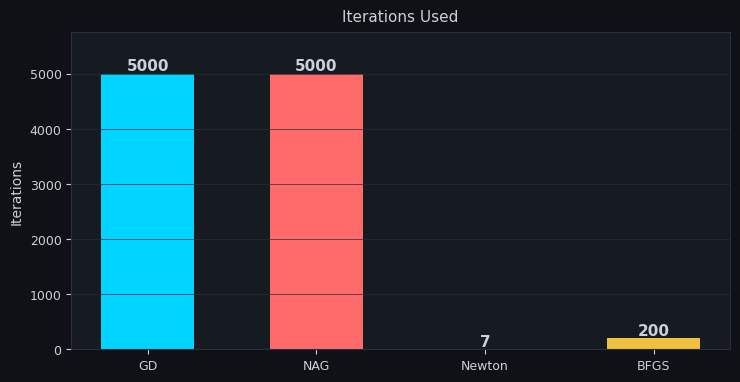

  ✓ cmp_01_iterations.png


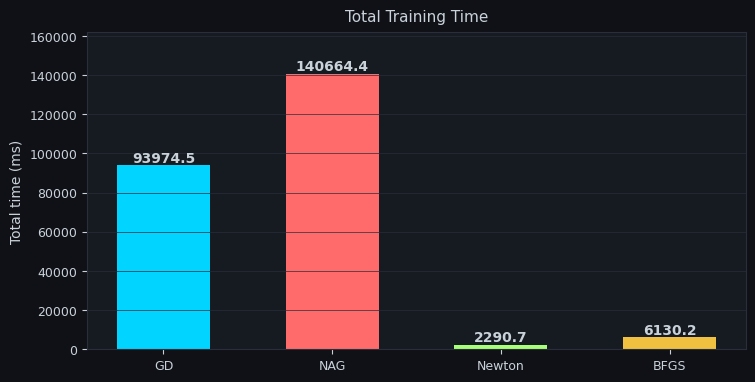

  ✓ cmp_02_total_time.png


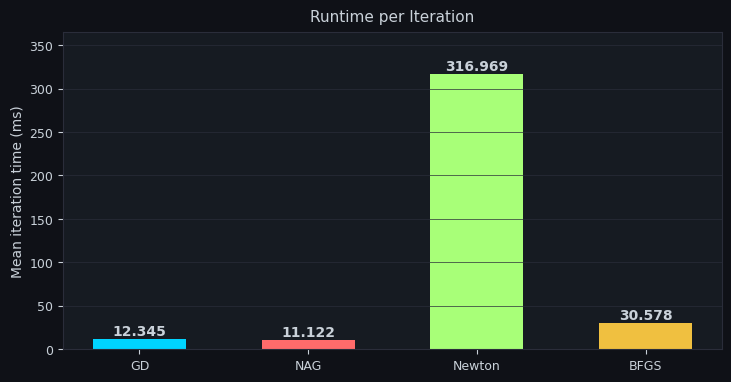

  ✓ cmp_03_iter_time.png


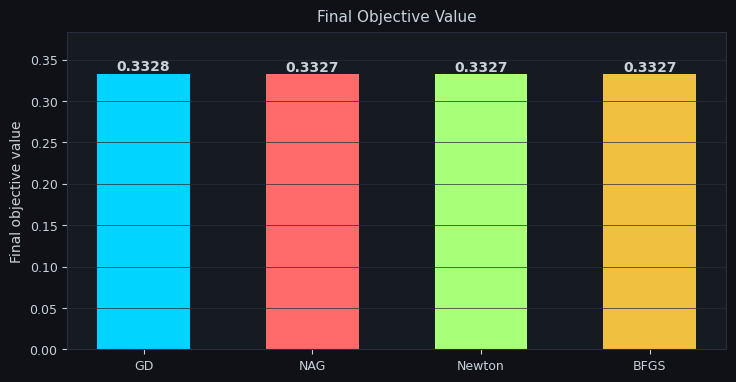

  ✓ cmp_04_final_loss.png


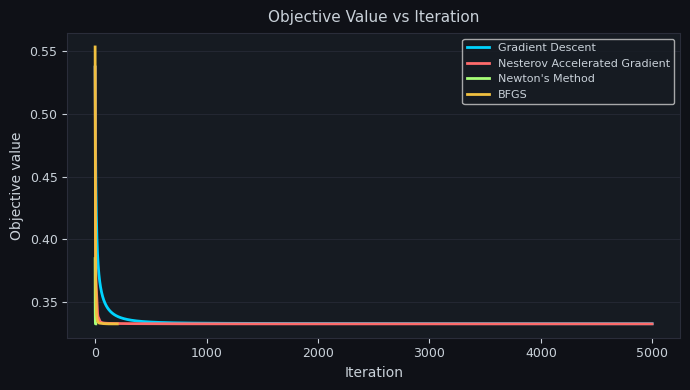

  ✓ cmp_05_loss_vs_iteration.png


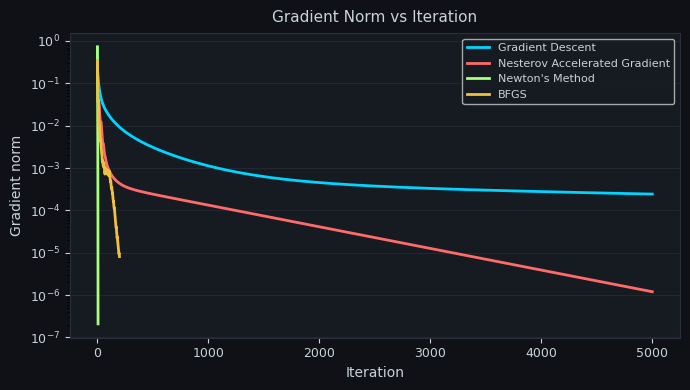

  ✓ cmp_06_grad_norm_vs_iteration.png


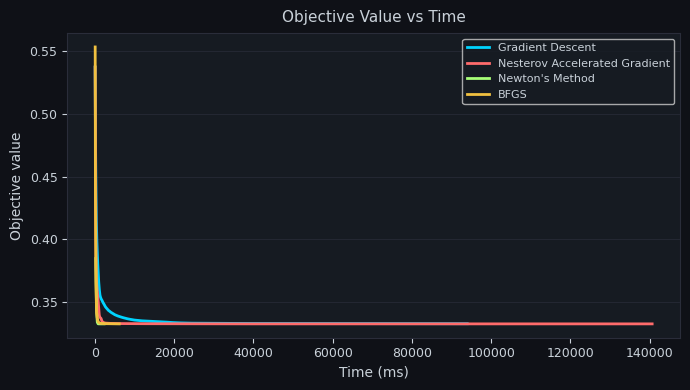

  ✓ cmp_07_loss_vs_time.png

Comparison plots done ✓


In [27]:
histories = {
    "Gradient Descent": history_gd,
    "Nesterov Accelerated Gradient": history_nag,
    "Newton's Method": history_nm,
    "BFGS": history_bfgs
}

plot_comparison(histories)

In [ ]:
# !rm -rf plots/*.png
# !ls plots

# scalability with problem size



In [28]:
def run_scalability_experiment(X_train, y_train, sizes, lam=1e-3):
    rows = []

    # One fixed random ordering for fair scalability comparison
    rng = np.random.default_rng(42)
    perm = rng.permutation(len(X_train))

    for size in sizes:
        size = min(size, len(X_train))
        idx = perm[:size]

        X_sub = X_train[idx]
        y_sub = y_train[idx]

        print(f"\nRunning scalability test with n = {size}")

        # 1. Gradient Descent
        w_gd_s, hist_gd_s = gradient_descent(
            X_sub, y_sub,
            num_iters=1500,
            lr=0.5,
            tol=1e-6,
            lam=lam,
            verbose=False
        )

        rows.append({
            "n_samples": size,
            "method": "Gradient Descent",
            "iterations": hist_gd_s["iters_run"],
            "total_time_ms": hist_gd_s["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_gd_s["iter_time"]) * 1e3,
            "final_loss": hist_gd_s["loss"][-1]
        })

        # 2. Nesterov Accelerated Gradient
        w_nag_s, hist_nag_s = nesterov_accelerated_gradient(
            X_sub, y_sub,
            num_iters=1500,
            lr=0.5,
            momentum=0.9,
            tol=1e-6,
            lam=lam,
            verbose=False
        )

        rows.append({
            "n_samples": size,
            "method": "Nesterov Accelerated Gradient",
            "iterations": hist_nag_s["iters_run"],
            "total_time_ms": hist_nag_s["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_nag_s["iter_time"]) * 1e3,
            "final_loss": hist_nag_s["loss"][-1]
        })

        # 3. Newton's Method
        w_nm_s, hist_nm_s = newtons_method(
            X_sub, y_sub,
            num_iters=30,
            tol=1e-6,
            lam=lam,
            reg=1e-8,
            verbose=False
        )

        rows.append({
            "n_samples": size,
            "method": "Newton's Method",
            "iterations": hist_nm_s["iters_run"],
            "total_time_ms": hist_nm_s["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_nm_s["iter_time"]) * 1e3,
            "final_loss": hist_nm_s["loss"][-1]
        })

        # 4. BFGS Quasi-Newton
        w_bfgs_s, hist_bfgs_s = bfgs_method(
            X_sub, y_sub,
            num_iters=80,
            tol=1e-6,
            lam=lam,
            verbose=False
        )

        rows.append({
            "n_samples": size,
            "method": "BFGS",
            "iterations": hist_bfgs_s["iters_run"],
            "total_time_ms": hist_bfgs_s["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_bfgs_s["iter_time"]) * 1e3,
            "final_loss": hist_bfgs_s["loss"][-1]
        })

    return pd.DataFrame(rows)


sizes = [1000, 5000, 10000, 20000, len(X_train)]
scalability_df = run_scalability_experiment(X_train, y_train, sizes, lam=LAM)
scalability_df


Running scalability test with n = 1000

  ✓ Converged at iteration 8 (‖∇L‖ = 4.43e-11)

Running scalability test with n = 5000

  ✓ Converged at iteration 7 (‖∇L‖ = 1.33e-07)

Running scalability test with n = 10000

  ✓ Converged at iteration 7 (‖∇L‖ = 7.45e-08)

Running scalability test with n = 20000

  ✓ Converged at iteration 7 (‖∇L‖ = 1.50e-07)

Running scalability test with n = 32561

  ✓ Converged at iteration 7 (‖∇L‖ = 2.10e-07)


,n_samples,method,iterations,total_time_ms,mean_iter_time_ms,final_loss
0,1000,Gradient Descent,1500,394.636578,0.146765,0.310596
1,1000,Nesterov Accelerated Gradient,1500,724.201575,0.171262,0.309624
2,1000,Newton's Method,8,26.232549,3.041526,0.309609
3,1000,BFGS,80,155.437817,1.905732,0.309879
4,5000,Gradient Descent,1500,4477.487078,1.875811,0.330993
5,5000,Nesterov Accelerated Gradient,1500,4486.214812,1.122104,0.330622
6,5000,Newton's Method,7,92.627482,12.555277,0.330613
7,5000,BFGS,80,320.828649,3.985036,0.330782
8,10000,Gradient Descent,1500,5131.930096,2.144728,0.336306
9,10000,Nesterov Accelerated Gradient,1500,10832.650425,2.776076,0.335925


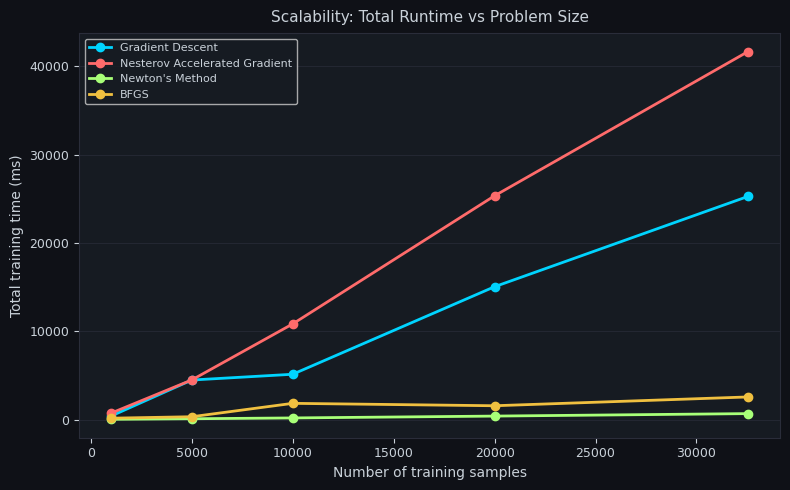

  ✓ cmp_08_scalability_total_runtime.png


In [29]:
def plot_scalability_runtime(scalability_df, output_dir="plots"):
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)

    for i, method in enumerate(scalability_df["method"].unique()):
        df_m = scalability_df[scalability_df["method"] == method]

        ax.plot(df_m["n_samples"],
                df_m["total_time_ms"],
                marker="o",
                label=method,
                color=_color(i),
                linewidth=2)

    ax.set_xlabel("Number of training samples")
    ax.set_ylabel("Total training time (ms)")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Scalability: Total Runtime vs Problem Size")
    fig.tight_layout()
    _save_show(fig, "cmp_08_scalability_total_runtime.png", output_dir)


plot_scalability_runtime(scalability_df)

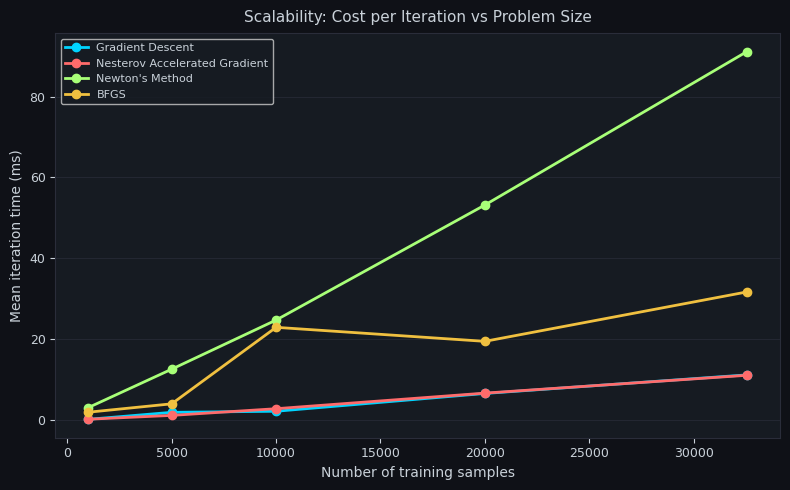

  ✓ cmp_09_scalability_iter_time.png


In [30]:
def plot_scalability_iter_time(scalability_df, output_dir="plots"):
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)

    for i, method in enumerate(scalability_df["method"].unique()):
        df_m = scalability_df[scalability_df["method"] == method]

        ax.plot(df_m["n_samples"],
                df_m["mean_iter_time_ms"],
                marker="o",
                label=method,
                color=_color(i),
                linewidth=2)

    ax.set_xlabel("Number of training samples")
    ax.set_ylabel("Mean iteration time (ms)")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Scalability: Cost per Iteration vs Problem Size")
    fig.tight_layout()
    _save_show(fig, "cmp_09_scalability_iter_time.png", output_dir)


plot_scalability_iter_time(scalability_df)

In [ ]:
# import shutil
# from google.colab import files

# shutil.make_archive("optimization_plots", "zip", "plots")
# files.download("optimization_plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## High-Dimensional Extension: Effect of Larger Feature Dimension

In [31]:
def load_w8a_dataset():
    train_url = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a"
    test_url  = "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a.t"

    if not os.path.exists("w8a"):
        urllib.request.urlretrieve(train_url, "w8a")

    if not os.path.exists("w8a.t"):
        urllib.request.urlretrieve(test_url, "w8a.t")

    X_train_sp, y_train, X_test_sp, y_test = load_svmlight_files(
        ["w8a", "w8a.t"],
        n_features=300
    )

    # Convert labels from {-1, +1} to {0, 1}
    y_train = (y_train == 1).astype(int)
    y_test = (y_test == 1).astype(int)

    # Convert to dense because Newton's Method uses dense Hessian operations
    X_train = X_train_sp.toarray()
    X_test = X_test_sp.toarray()

    # Add bias column
    X_train = np.c_[X_train, np.ones(X_train.shape[0])]
    X_test = np.c_[X_test, np.ones(X_test.shape[0])]

    print("\nDataset  : LIBSVM w8a")
    print(f"Samples  : {len(y_train) + len(y_test)} "
          f"(train {len(X_train)}, test {len(X_test)})")
    print(f"Features : {X_train.shape[1]} including bias")
    print(f"Class balance (train) — 0: {(y_train == 0).sum()}  1: {(y_train == 1).sum()}")

    return X_train, X_test, y_train, y_test


X_train_w8a, X_test_w8a, y_train_w8a, y_test_w8a = load_w8a_dataset()


Dataset  : LIBSVM w8a
Samples  : 64700 (train 49749, test 14951)
Features : 301 including bias
Class balance (train) — 0: 48270  1: 1479


In [32]:
def run_dimension_extension_w8a(X_train, y_train, sizes, lam=1e-3):
    rows = []

    rng = np.random.default_rng(42)
    perm = rng.permutation(len(X_train))

    for size in sizes:
        size = min(size, len(X_train))
        idx = perm[:size]

        X_sub = X_train[idx]
        y_sub = y_train[idx]

        print(f"\nRunning w8a dimension test with n = {size}, d = {X_sub.shape[1]}")

        # Gradient Descent
        w_gd_d, hist_gd_d = gradient_descent(
            X_sub, y_sub,
            num_iters=1000,
            lr=0.5,
            tol=1e-6,
            lam=lam,
            verbose=False
        )

        rows.append({
            "dataset": "w8a",
            "n_samples": size,
            "n_features": X_sub.shape[1],
            "method": "Gradient Descent",
            "iterations": hist_gd_d["iters_run"],
            "total_time_ms": hist_gd_d["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_gd_d["iter_time"]) * 1e3,
            "final_loss": hist_gd_d["loss"][-1]
        })

        # Nesterov Accelerated Gradient
        w_nag_d, hist_nag_d = nesterov_accelerated_gradient(
            X_sub, y_sub,
            num_iters=1000,
            lr=0.5,
            momentum=0.9,
            tol=1e-6,
            lam=lam,
            verbose=False
        )

        rows.append({
            "dataset": "w8a",
            "n_samples": size,
            "n_features": X_sub.shape[1],
            "method": "Nesterov Accelerated Gradient",
            "iterations": hist_nag_d["iters_run"],
            "total_time_ms": hist_nag_d["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_nag_d["iter_time"]) * 1e3,
            "final_loss": hist_nag_d["loss"][-1]
        })

        # Newton's Method
        w_nm_d, hist_nm_d = newtons_method(
            X_sub, y_sub,
            num_iters=30,
            tol=1e-6,
            lam=lam,
            reg=1e-8,
            verbose=False
        )

        rows.append({
            "dataset": "w8a",
            "n_samples": size,
            "n_features": X_sub.shape[1],
            "method": "Newton's Method",
            "iterations": hist_nm_d["iters_run"],
            "total_time_ms": hist_nm_d["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_nm_d["iter_time"]) * 1e3,
            "final_loss": hist_nm_d["loss"][-1]
        })

        # BFGS
        w_bfgs_d, hist_bfgs_d = bfgs_method(
            X_sub, y_sub,
            num_iters=60,
            tol=1e-6,
            lam=lam,
            verbose=False
        )

        rows.append({
            "dataset": "w8a",
            "n_samples": size,
            "n_features": X_sub.shape[1],
            "method": "BFGS",
            "iterations": hist_bfgs_d["iters_run"],
            "total_time_ms": hist_bfgs_d["total_time"] * 1e3,
            "mean_iter_time_ms": np.mean(hist_bfgs_d["iter_time"]) * 1e3,
            "final_loss": hist_bfgs_d["loss"][-1]
        })

    return pd.DataFrame(rows)


w8a_sizes = [1000, 5000, 10000, 20000, 40000]
dimension_extension_df = run_dimension_extension_w8a(
    X_train_w8a,
    y_train_w8a,
    w8a_sizes,
    lam=LAM
)

dimension_extension_df


Running w8a dimension test with n = 1000, d = 301

  ✓ Converged at iteration 8 (‖∇L‖ = 8.29e-07)

Running w8a dimension test with n = 5000, d = 301

  ✓ Converged at iteration 8 (‖∇L‖ = 3.82e-07)

Running w8a dimension test with n = 10000, d = 301

  ✓ Converged at iteration 8 (‖∇L‖ = 2.66e-07)

Running w8a dimension test with n = 20000, d = 301

  ✓ Converged at iteration 8 (‖∇L‖ = 2.73e-07)

Running w8a dimension test with n = 40000, d = 301

  ✓ Converged at iteration 8 (‖∇L‖ = 3.05e-07)


,dataset,n_samples,n_features,method,iterations,total_time_ms,mean_iter_time_ms,final_loss
0,w8a,1000,301,Gradient Descent,1000,497.591072,0.305073,0.062053
1,w8a,1000,301,Nesterov Accelerated Gradient,1000,767.400357,0.287839,0.057269
2,w8a,1000,301,Newton's Method,8,105.771691,12.726733,0.057269
3,w8a,1000,301,BFGS,60,503.203598,8.260990,0.057329
4,w8a,5000,301,Gradient Descent,1000,3786.387789,2.462081,0.086679
5,w8a,5000,301,Nesterov Accelerated Gradient,1000,8039.783618,3.183009,0.083449
6,w8a,5000,301,Newton's Method,8,422.268141,50.830174,0.083449
7,w8a,5000,301,BFGS,60,896.133379,14.772386,0.083489
8,w8a,10000,301,Gradient Descent,1000,9778.833927,6.486349,0.087920
9,w8a,10000,301,Nesterov Accelerated Gradient,1000,16565.415355,6.611616,0.085437


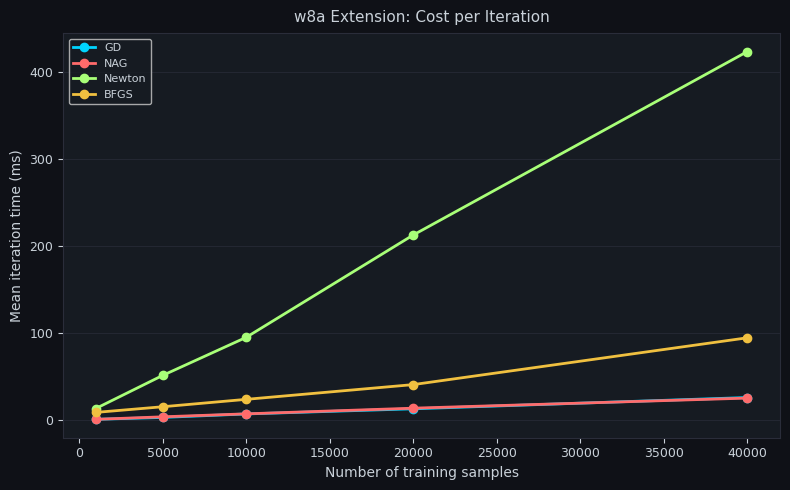

  ✓ cmp_10_w8a_iter_time.png


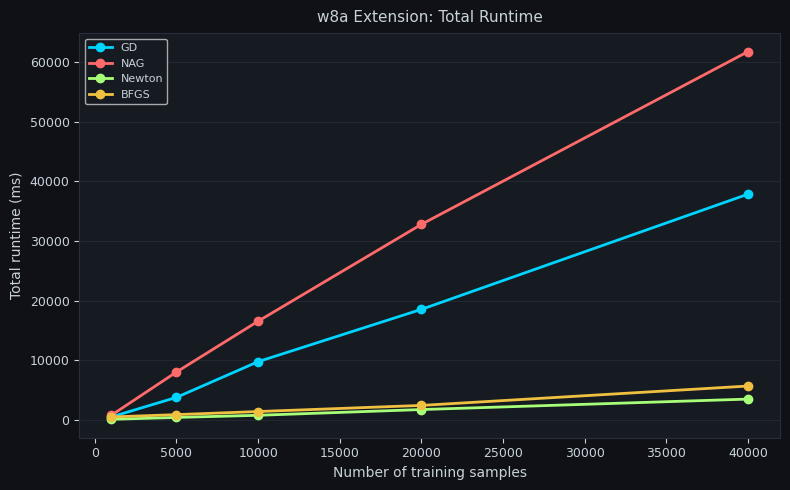

  ✓ cmp_11_w8a_total_runtime.png


In [33]:
def plot_w8a_dimension_extension(dimension_extension_df, output_dir="plots"):
    os.makedirs(output_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)

    for i, method in enumerate(dimension_extension_df["method"].unique()):
        df_m = dimension_extension_df[dimension_extension_df["method"] == method]

        ax.plot(df_m["n_samples"],
                df_m["mean_iter_time_ms"],
                marker="o",
                label=_short_name(method),
                color=_color(i),
                linewidth=2)

    ax.set_xlabel("Number of training samples")
    ax.set_ylabel("Mean iteration time (ms)")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "w8a Extension: Cost per Iteration")
    fig.tight_layout()
    _save_show(fig, "cmp_10_w8a_iter_time.png", output_dir)

    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)

    for i, method in enumerate(dimension_extension_df["method"].unique()):
        df_m = dimension_extension_df[dimension_extension_df["method"] == method]

        ax.plot(df_m["n_samples"],
                df_m["total_time_ms"],
                marker="o",
                label=_short_name(method),
                color=_color(i),
                linewidth=2)

    ax.set_xlabel("Number of training samples")
    ax.set_ylabel("Total runtime (ms)")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "w8a Extension: Total Runtime")
    fig.tight_layout()
    _save_show(fig, "cmp_11_w8a_total_runtime.png", output_dir)


plot_w8a_dimension_extension(dimension_extension_df)

## Newton Scalability Comparison: a9a vs w8a

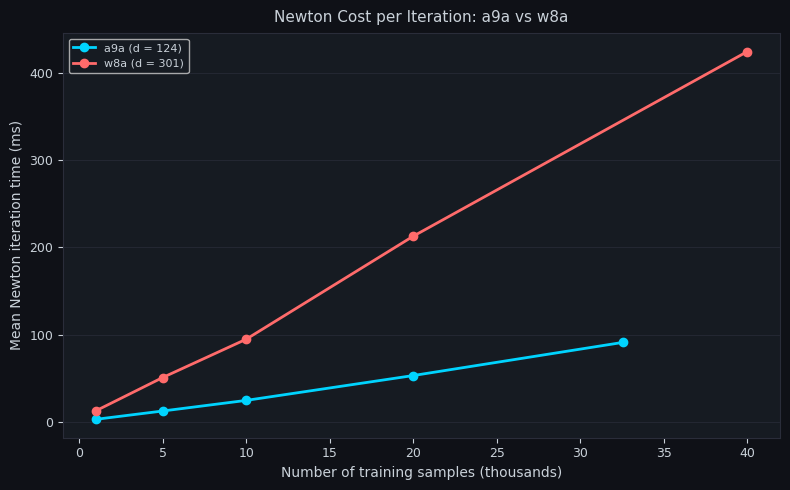

  ✓ cmp_10_newton_iter_time_a9a_vs_w8a.png


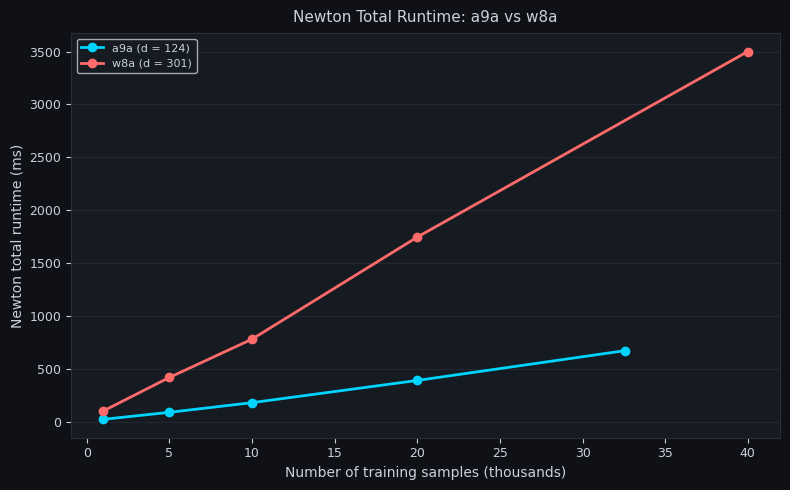

  ✓ cmp_11_newton_total_runtime_a9a_vs_w8a.png


,n_samples,method,iterations,total_time_ms,mean_iter_time_ms,final_loss,dataset,n_features,n_thousands
0,1000,Newton's Method,8,26.232549,3.041526,0.309609,a9a (d = 124),NaN,1.000
1,5000,Newton's Method,7,92.627482,12.555277,0.330613,a9a (d = 124),NaN,5.000
2,10000,Newton's Method,7,183.737496,24.704043,0.335914,a9a (d = 124),NaN,10.000
3,20000,Newton's Method,7,393.683184,53.163120,0.334667,a9a (d = 124),NaN,20.000
4,32561,Newton's Method,7,674.703981,91.142453,0.332713,a9a (d = 124),NaN,32.561
5,1000,Newton's Method,8,105.771691,12.726733,0.057269,w8a (d = 301),301.0,1.000
6,5000,Newton's Method,8,422.268141,50.830174,0.083449,w8a (d = 301),301.0,5.000
7,10000,Newton's Method,8,783.754343,94.700250,0.085437,w8a (d = 301),301.0,10.000
8,20000,Newton's Method,8,1747.631229,212.638703,0.087940,w8a (d = 301),301.0,20.000
9,40000,Newton's Method,8,3500.247493,424.038152,0.086149,w8a (d = 301),301.0,40.000


In [34]:
def plot_newton_a9a_vs_w8a(scalability_df, dimension_extension_df, output_dir="plots"):
    os.makedirs(output_dir, exist_ok=True)

    # Filter Newton only from both experiments
    newton_a9a = scalability_df[
        scalability_df["method"] == "Newton's Method"
    ].copy()

    newton_w8a = dimension_extension_df[
        dimension_extension_df["method"] == "Newton's Method"
    ].copy()

    newton_a9a["dataset"] = "a9a (d = 124)"
    newton_w8a["dataset"] = "w8a (d = 301)"

    newton_compare_df = pd.concat([newton_a9a, newton_w8a], ignore_index=True)

    # Use n in thousands for cleaner x-axis
    newton_compare_df["n_thousands"] = newton_compare_df["n_samples"] / 1000

    # Plot 1: Newton mean iteration time
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)

    for i, dataset in enumerate(newton_compare_df["dataset"].unique()):
        df_d = newton_compare_df[newton_compare_df["dataset"] == dataset]

        ax.plot(
            df_d["n_thousands"],
            df_d["mean_iter_time_ms"],
            marker="o",
            linewidth=2,
            label=dataset,
            color=_color(i)
        )

    ax.set_xlabel("Number of training samples (thousands)")
    ax.set_ylabel("Mean Newton iteration time (ms)")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Newton Cost per Iteration: a9a vs w8a")
    fig.tight_layout()
    _save_show(fig, "cmp_10_newton_iter_time_a9a_vs_w8a.png", output_dir)

    # Plot 2: Newton total runtime
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)

    for i, dataset in enumerate(newton_compare_df["dataset"].unique()):
        df_d = newton_compare_df[newton_compare_df["dataset"] == dataset]

        ax.plot(
            df_d["n_thousands"],
            df_d["total_time_ms"],
            marker="o",
            linewidth=2,
            label=dataset,
            color=_color(i)
        )

    ax.set_xlabel("Number of training samples (thousands)")
    ax.set_ylabel("Newton total runtime (ms)")
    ax.legend(fontsize=8, labelcolor=TEXT_C, facecolor=AX_BG)
    _style(ax, "Newton Total Runtime: a9a vs w8a")
    fig.tight_layout()
    _save_show(fig, "cmp_11_newton_total_runtime_a9a_vs_w8a.png", output_dir)

    return newton_compare_df


newton_compare_df = plot_newton_a9a_vs_w8a(
    scalability_df,
    dimension_extension_df
)

newton_compare_df

In [35]:
# import shutil
# from google.colab import files

# shutil.make_archive("optimization_plots", "zip", "plots")
# files.download("optimization_plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>